In [1]:
import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import geometry
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import contextily as cx
from MODE_top_level import RegionalModel
from syspy.skims import skims

C:\Users\m.arnz\AppData\Local\miniforge-pypy3\envs\quetzal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-09 13:22:39,143	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
figsize = 16

In [3]:
# Load the region of interest
region_name = 'SevilleFUA'
scenario = ''
regio_df = gpd.read_file('../model/'+region_name+'/region_geometries.geojson').set_index('index').set_crs(4326)
polygon = regio_df.loc['city', 'geometry']
buffer = 0.01
# Instantiate the model
model = RegionalModel(polygon=polygon, buffer_size=buffer, epsg=4326, coordinates_unit='degree')

In [4]:
# Load networks
model.load_networks_road('../model/'+region_name+'/networks_road/')
model.load_network_pt('../model/'+region_name+'/networks_pt/')

In [5]:
# Load origins and destinations
zones = gpd.read_file('../model/'+region_name+'/zones.geojson').to_crs(regio_df.crs)
pois = gpd.read_file('../model/'+region_name+'/pois.geojson').to_crs(regio_df.crs)

# Build trip chains

Apply trip frequencies to construct daily schedules. Trip chains with less than daily trip frequencies have a respectively lower weighting.

In [6]:
activities = list(pois['activity'].unique())
home_activity = '0'

In [7]:
# Load trip frequencies
trips = pd.read_excel('../input/decent_mobility_trips.xlsx', sheet_name=1, skiprows=1)
trips = trips.loc[trips['name'].notna()].set_index('name')
trips['1'] = trips['Commuting and business']
trips['2'] = trips['Education']
trips['3'] = trips['Accompaniment']
trips['6'] = trips['Healthcare']
trips['7'] = trips['Recreational and outdoors']
trips['41'] = trips['Social and cultural'] * 0.6
trips['42'] = trips['Social and cultural'] * 0.4
trips['51'] = trips['Shopping and errands'] / 2
trips['52'] = trips['Shopping and errands'] / 2
trips[home_activity] = trips['Home']
trips = trips[activities + [home_activity]]
model.segments = list(trips.index)
trips * 7

,1,2,3,41,42,51,52,6,7,0
name,,,,,,,,,,
Single worker,4.0,0.0,0,1.2,0.8,0.5,0.5,0.0,2.0,4.5
Caring worker,4.0,0.0,7,1.2,0.8,0.5,0.5,0.0,2.0,7.0
Disabled elderly,0.0,0.0,0,1.2,0.8,0.5,0.5,1.0,2.0,3.0
Disabled caring worker,4.0,0.0,7,1.2,0.8,0.5,0.5,1.0,2.0,7.0


In [8]:
# Define a temporal order for activities
# Activities must have the same name as in the POI data
# '0' stands for go home
# For now, the same schedule for all personas
# Work should be scheduled first because the OD table has no paths from POIs to workplaces
# '2' should be scheduled second for the same reason
persona_schedule_order = {}
for persona in model.segments:
    persona_schedule_order[persona] = ['1', '2', '6', '3', '51', '52', '42', '41', '7', home_activity]

In [9]:
# Differentiate trip chains by their frequency
persona_schedules = {p: {} for p in model.segments}
for persona in model.segments:
    freqs = trips.loc[persona].sort_values(ascending=False).to_dict()
    sort_order = dict(zip(persona_schedule_order[persona], range(len(persona_schedule_order[persona]))))
    while len(freqs) > 0:
        act, freq = freqs.popitem() # take the lowest frequency trip
        if freq > 0 and act != home_activity:
            activities_to_do = [a for a,f in freqs.items() if f>=freq and a!=home_activity] + [act, home_activity]
            activities_to_do.sort(key=lambda val: sort_order[val]) # sort by schedule order
            persona_schedules[persona][freq] = activities_to_do.copy()
            freqs = {a: f - freq for a,f in freqs.items()} # update residual frequencies
# Results
df = pd.DataFrame(columns=model.segments, index=trips.columns)
for persona in model.segments:
    s = pd.Series(persona_schedules[persona]).explode()
    df[persona] = pd.DataFrame({persona:s.index, 'act':s.values}).groupby('act').sum() * 7
df.T.fillna(0)

,1,2,3,41,42,51,52,6,7,0
Single worker,4.0,0.0,0.0,1.2,0.8,0.5,0.5,0.0,2.0,4.0
Caring worker,4.0,0.0,7.0,1.2,0.8,0.5,0.5,0.0,2.0,7.0
Disabled elderly,0.0,0.0,0.0,1.2,0.8,0.5,0.5,1.0,2.0,2.0
Disabled caring worker,4.0,0.0,7.0,1.2,0.8,0.5,0.5,1.0,2.0,7.0


# Location choice

For each persona, choose a set of destinations as need satisfiers based on their journeys

In [10]:
# Distribute personas across a number of home locations
# All personas are distributed across the same home locations
homes = list(zones['cluster'].unique())

Text(0.5, 0, 'distance [km]')

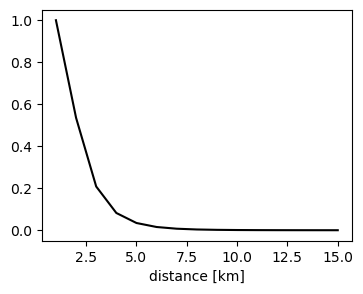

In [11]:
# Create the distance deterrence with a gravity model for each OD pair
# Log-normal function
def deterrence_func(d, a=1, b=1.3):
    return a * np.exp(-b * np.power(np.log(d), 2))
fig, ax = plt.subplots(1,1, figsize=(4,3))
d = np.arange(1, 16)
ax.plot(d, deterrence_func(d), color='black', marker='')
ax.set_xlabel('distance [km]')

Text(0.5, 0, 'time [min]')

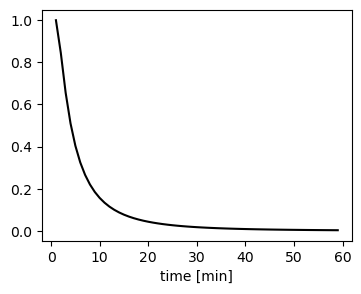

In [12]:
# Create the time deterrence function
def deterrence_func_time(d, a=1, b=0.35):
    return a * np.exp(-b * np.power(np.log(d), 2))
fig, ax = plt.subplots(1,1, figsize=(4,3))
d = np.arange(1, 60)
ax.plot(d, deterrence_func_time(d), color='black', marker='')
ax.set_xlabel('time [min]')

In [13]:
# Choose one location for each activity in each schedule
# Same choice for all personas of every one home zone
# Choose location based on walking distance
distance_calc = 'geometry' # 'network' takes significantly longer but allows for transit-oriented development
file_name = f'../model/{region_name}/{scenario}persona_locations_{distance_calc}.json'
fixed_location_activities = ['1', '2', '3', '6']

if not os.path.exists(file_name):
    persona_locations = {}
    for home in homes:
        persona_locations[home] = {}
        for persona in model.segments:
            persona_locations[home][persona] = {}

            # Fix one location for each compulsory activity type
            fixed_locations = {}
            for activity in fixed_location_activities:
                pois_activity = pois.loc[pois['activity']==activity]
                destinations = pois_activity['origin_id']
                dist = skims.distance_from_geometry(pd.Series(
                    [geometry.LineString((zones.set_index('cluster').loc[home, 'geometry'].centroid.coords[0], d.coords[0]))
                     for d in pois_activity['geometry']]
                )).astype(int) / 1000
                dist.index = destinations
                deterrence = dist.clip(lower=1).apply(deterrence_func)
                sizes = pois_activity.set_index('origin_id').loc[destinations, 'dest_weight']
                prob = sizes * deterrence
                prob = prob / prob.sum()
                location = np.random.choice(destinations, 1, replace=False, p=prob)[0]
                fixed_locations[activity] = location

            # Build dependent trip chains
            for freq, schedule in persona_schedules[persona].items():
                # Start at home
                persona_locations[home][persona][freq] = [home]
                last_geo = zones.set_index('cluster').loc[home, 'geometry'].centroid
                for activity in schedule:
                    if activity == home_activity:
                        persona_locations[home][persona][freq].append(home)
                    elif activity in fixed_location_activities:
                        persona_locations[home][persona][freq].append(fixed_locations[activity])
                    else:
                        # Compute distances with walking pathfinder
                        pois_activity = pois.loc[pois['activity']==activity]
                        od_df = pd.DataFrame({
                            'origin_id': [persona_locations[home][persona][freq][-1]] * len(pois_activity),
                            'destination_id': list(pois_activity['origin_id']),
                            'origin': [last_geo] * len(pois_activity),
                            'destination': pois_activity['geometry'],
                            'activity': [activity] * len(pois_activity)
                        })
                        if distance_calc == 'network':
                            if 'isabled' in persona:
                                model.pt_links['headway'].clip(lower=5*60, upper=20*60, inplace=True)
                                model.pathfinding_public_transport(od_df, weekday='Thu')
                                los = model.pt_los.sort_values('time', ascending=True).drop_duplicates(['origin', 'destination'], keep='first')
                            else:
                                model.pathfinding_auto(od_df)
                                los = model.auto_los.sort_values('time', ascending=True).drop_duplicates(['origin', 'destination'], keep='first')
                            destinations = list(los['destination'])
                            deterrence = los.set_index('destination')['time'].clip(lower=1).apply(deterrence_func_time)
                        elif distance_calc == 'geometry':
                            destinations = list(od_df['destination_id'])
                            dist = skims.distance_from_geometry(pd.Series(
                                [geometry.LineString((o.coords[0], d.coords[0])) for o,d in zip(od_df['origin'], od_df['destination'])]
                            )).astype(int) / 1000
                            dist.index = destinations
                            deterrence = dist.clip(lower=1).apply(deterrence_func)
                        
                        # Choose randomly with deterrence and POI size as weight
                        sizes = pois_activity.set_index('origin_id').loc[destinations, 'dest_weight']
                        prob = sizes * deterrence
                        prob = prob / prob.sum()
                        location = np.random.choice(destinations, 1, replace=False, p=prob)[0]
                        persona_locations[home][persona][freq].append(location)
                        # Save last location
                        last_geo = pois.set_index('origin_id').loc[location, 'geometry']
    with open(file_name, 'w') as file:
        json.dump(persona_locations, file)
else:
    with open(file_name, 'r') as file:
        persona_locations = json.load(file)
persona_locations[homes[0]]

{'Single worker': {'0.07142857142857142': ['0_home',
   '216_work',
   '164_groceries',
   '57_errands',
   '3_cultural',
   '71_social',
   '32_recreational',
   '0_home'],
  '0.04285714285714286': ['0_home',
   '216_work',
   '18_cultural',
   '187_social',
   '45_recreational',
   '0_home'],
  '0.05714285714285712': ['0_home',
   '216_work',
   '162_social',
   '70_recreational',
   '0_home'],
  '0.11428571428571431': ['0_home', '216_work', '67_recreational', '0_home'],
  '0.2857142857142857': ['0_home', '216_work', '0_home']},
 'Caring worker': {'0.07142857142857142': ['0_home',
   '118_work',
   '182_accompaniment',
   '176_groceries',
   '126_errands',
   '151_cultural',
   '44_social',
   '165_recreational',
   '0_home'],
  '0.04285714285714286': ['0_home',
   '118_work',
   '182_accompaniment',
   '15_cultural',
   '72_social',
   '20_recreational',
   '0_home'],
  '0.05714285714285712': ['0_home',
   '118_work',
   '182_accompaniment',
   '123_social',
   '56_recreational',
  

In [14]:
if scenario == 'care_everywhere_':
    # Replace accompany POIs with population zone centroids
    pois = pois.loc[~pois['origin_id'].str.contains('accompan')]
    new = gpd.GeoDataFrame({'origin_id': [str(i)+'_accompaniment' for i in zones['cluster'].apply(lambda s: s.split('_')[0])]},
                           geometry=zones.centroid)
    new['dest_weight'] = 1
    new['activity'] = '3'
    pois = gpd.GeoDataFrame(pd.concat([pois, new]).reset_index(drop=True)).set_crs(regio_df.crs)

    # Replace accompany activity locations with home zone
    for home, personas in persona_locations.items():
        for persona, schedules in personas.items():
            if 'Caring' in persona or 'caring' in persona:
                for freq, schedule in schedules.items():
                    to_replace = [i for i in schedule if 'accompan' in i]
                    if len(to_replace) > 0:
                        for i in to_replace:
                            schedule[schedule.index(i)] = home.split('_')[0] + '_accompaniment'

In [15]:
# Plot paths
def get_geo(poi):
    if 'home' in poi:
        return zones.set_index('cluster').loc[poi, 'geometry'].centroid
    else:
        return pois.set_index('origin_id').loc[poi, 'geometry']

def plot_paths(persona_dict, ax):
    colors = iter(cm.rainbow(np.linspace(0, 1, len(persona_dict))))
    for persona, schedules in persona_dict.items():
        color = next(colors)
        for i, (freq, schedule) in enumerate(schedules.items()):
            paths = gpd.GeoDataFrame(
                geometry=[geometry.LineString((get_geo(schedule[j]), get_geo(schedule[j+1])))
                          for j in range(len(schedule)-1)]
            ).set_crs(regio_df.crs)
            ax = paths.plot(ax=ax, color=color, alpha=min(float(freq)*2+0.1, 1), label=persona if i==len(schedules)-1 else None)
    ax.legend()
    return ax

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(figsize/2,figsize/2))
home = homes[0]
ax = plot_paths(persona_locations[home], ax)
ax = pois.plot(ax=ax, color='black', markersize=pois['dest_weight'], alpha=.2)
cx.add_basemap(ax=ax, crs='EPSG:4326', zoom=13, source=cx.providers.CartoDB.Positron)
plt.savefig('../output/'+region_name+'/'+scenario+'paths_'+home+'.png', dpi=400, bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(figsize/2,figsize/2))
home = homes[30]
ax = plot_paths(persona_locations[home], ax)
ax = pois.plot(ax=ax, color='black', markersize=pois['dest_weight'], alpha=.2)
cx.add_basemap(ax=ax, crs='EPSG:4326', zoom=13, source=cx.providers.CartoDB.Positron)
plt.savefig('../output/'+region_name+'/'+scenario+'paths_'+home+'.png', dpi=400, bbox_inches='tight')

# Mode choice simulation

Create mode choice probabilities for OD pairs

In [17]:
# Generate one OD table with all connections from the schedules
od_df = pd.DataFrame()
for home, personas in persona_locations.items():
    for persona, schedules in personas.items():
        for freq, schedule in schedules.items():
            geos = [get_geo(i) for i in schedule]
            a = [i.split('_')[1] for i in schedule]
            od = pd.DataFrame({
                'origin_id': schedule[:-1],
                'destination_id': schedule[1:],
                'origin': geos[:-1],
                'destination': geos[1:],
                'activity': a[1:],
                #'frequency': [float(freq)] * (len(a)-1)
            })
            od_df = pd.concat([od, od_df])
od_df = od_df.drop_duplicates() #['origin_id', 'destination_id', 'activity'])
len(od_df)

2961

In [24]:
# Pathfinding car
if scenario != 'car_free_':
    model.pathfinding_auto(od_df)
    print('car paths', len(model.auto_los))
else:
    restricted = regio_df.loc['inner_city' if 'inner_city' in regio_df.index else 'city', 'geometry']
    od_df_car = od_df.loc[~(gpd.GeoDataFrame(od_df, geometry='destination')['destination'].within(restricted))].copy()
    if len(od_df_car) > 0:
        model.pathfinding_auto(od_df_car)
        print('car paths', len(model.auto_los))
    else:
        model.auto_los = pd.DataFrame(columns=model.walk_los.columns)

self.volumes does not exist. od generated with self.zones
car paths 2341


In [20]:
# Pathfinding
model.pathfinding_walk(od_df)
print('walking paths', len(model.walk_los))
model.pathfinding_cycling(od_df)
print('cycling paths', len(model.cycle_los))
model.pt_links['headway'].clip(lower=5*60, upper=20*60, inplace=True) # correct PT links, max waiting time 10 min
model.pathfinding_public_transport(od_df, weekday='Thu') # best metro schedule is on Thursday
print('PT paths', len(model.pt_los))

self.volumes does not exist. od generated with self.zones
walking paths 2961
self.volumes does not exist. od generated with self.zones
cycling paths 2961


path_analysis: 100%|████████████████████████████████████████████████████████████| 2961/2961 [00:00<00:00, 66882.08it/s]


PT paths 2961


826


<Axes: xlabel='length', ylabel='time'>

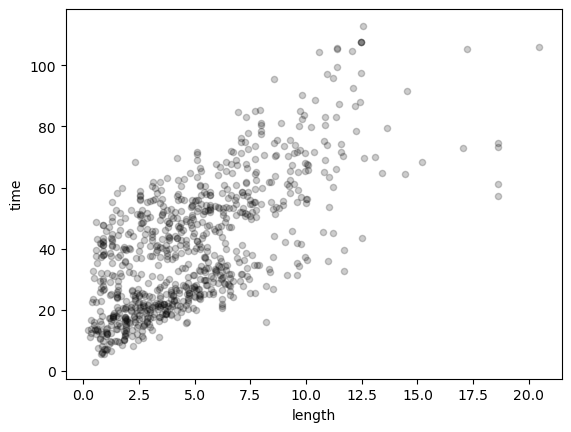

In [21]:
# Clean PT LoS
model.pt_los = model.pt_los.loc[model.pt_los['ntlegs'].apply(lambda l: len(l)==2)]
model.pt_los = model.pt_los.loc[~(model.pt_los['all_walk'])]
print(len(model.pt_los))
model.pt_los.plot.scatter(x='length', y='time', color='black', alpha=.2)

In [25]:
# Compute mode choice probabilities
los_attributes=['time', 'price']
model.load_estimation_parameters(f'../input/{region_name}/mode_choice_.xlsx',
                                 mode_asc_0 = 'car',
                                 modes_list = ['pt','walk','bicycle','car'] if len(model.auto_los)>0 else ['pt','walk','bicycle'],
                                 los_attributes=los_attributes)
if 'price' in los_attributes:
    model.walk_los['price'] = 0
    model.cycle_los['price'] = 0
    model.auto_los['price'] = model.auto_los['length'] * 0.14
    model.pt_los['price'] = model.pt_los['ntransfers'].apply(
        lambda x: 0.35 if x==0 else (0.46 if x==1 else 0.6))
    model.pt_los.loc[model.pt_los['route_types'].apply(lambda l: 'metro' in l), 'price'] = \
        model.pt_los.loc[model.pt_los['route_types'].apply(lambda l: 'metro' in l), 'ntransfers'].apply(
            lambda x: 0.49 if x==0 else (0.7 if x==1 else 0.82))
model.los = pd.concat([model.auto_los, model.cycle_los, model.walk_los, model.pt_los]).reset_index(drop=True)
for a in los_attributes:
    for s in model.segments:
        if not s+'_'+a in model.los.columns:
            model.los[s+'_'+a] = model.los[a]
model.analysis_mode_utility(how='main', segment=None)
model.step_logit()

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]C:\Users\m.arnz\AppData\Local\miniforge-pypy3\envs\quetzal\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\m.arnz\AppData\Local\miniforge-pypy3\envs\quetzal\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
 10%|████████▎                                                                          | 1/10 [00:00<00:01,  8.12it/s]C:\Users\m.arnz\AppData\Local\miniforge-pypy3\envs\quetzal\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\m.arnz\AppData\Local\miniforge-pypy3\envs\quetzal\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by

In [26]:
model.probabilities.sample(2)

route_type,origin,destination,segment,root,bicycle,walk,car,pt
236,124_recreational,28_home,Caring worker,1,0.140766,0.282291,0.576943,0.0
60,107_work,57_accompaniment,Caring worker,1,0.106060,0.270192,0.623748,0.0


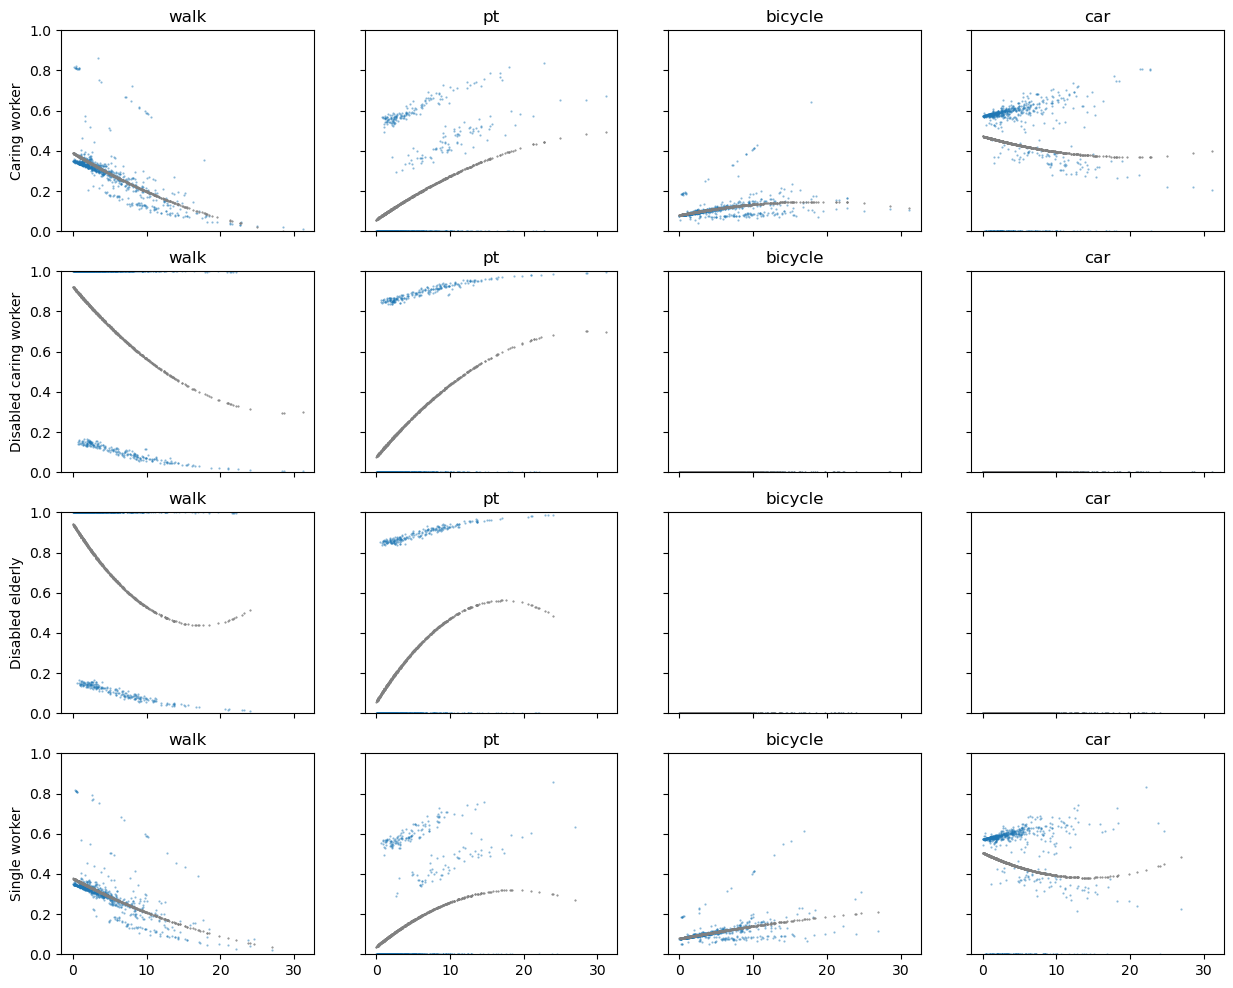

In [27]:
# Distance-distribution (based on walking paths) of probabilities
merged = model.probabilities.merge( #.sample(max(int(len(model.probabilities)**0.5), 100000))
    model.walk_los[['origin', 'destination', 'length']],
    on=['origin', 'destination'],
    how='inner').sample(min(len(model.walk_los), 5000))
segments = list(model.probabilities['segment'].unique())
if len(segments) == 1: segments = segments * 2
route_types = list(set(model.probabilities.columns).intersection(set(model.los['route_type'])))
fig, ax = plt.subplots(nrows=len(segments), ncols=len(route_types),
                        sharex='all', sharey='all', figsize=(15,len(segments)*3))
for j, mode in zip(range(len(route_types)), route_types):
    for i, seg in zip(range(len(segments)), segments):
        x = merged.loc[merged['segment']==seg, 'length']
        y = merged.loc[merged['segment']==seg, mode]
        ax[i,j].scatter(x, y, marker='o', s=.3, alpha=.5, label=mode+' '+seg)
        p = np.poly1d(np.polyfit(x, y, deg=2))
        ax[i,j].plot(x, p(x), linestyle='', marker='o', markersize=.5, color='grey', label=mode+' '+seg)
        ax[i,j].set_title(mode)
        ax[i,0].set_ylabel(seg)
        ax[i,0].set_ylim(0,1)
        #ax[i,j].set_xscale('log')
plt.savefig('../output/'+region_name+'/'+scenario+'mode_choice_probability_distribution.png', dpi=400)

# Network assignment

Generate resulting traffic

In [28]:
# Assign trip chains to the networks based on mode choice probabilities
# Take the first leg of the trip chain as mode choice decision criterion
# Perform this for every persona in every home location
results = {}
modes = [c for c in model.probabilities.columns if c in model.los['route_type'].unique()]
for persona in tqdm(model.segments):
    paths = []
    for home in homes:
        for freq, schedule in persona_locations[home][persona].items():
            # Choose mode based on all trips of the journey
            decision_leg = model.probabilities.loc[
                (model.probabilities['segment']==persona)
                & (model.probabilities['origin'].isin(schedule))
                & (model.probabilities['destination'].isin(schedule))
            ]
            if len(decision_leg) > 1:
                prob = decision_leg[modes].mean().values
            else:
                prob = decision_leg[modes].values[0]
            mode = np.random.choice(modes, 1, p=prob)[0]
            # Look up the travel characteristics of each leg in the corresponding LoS table
            los = model.__dict__[mode.replace('car', 'auto').replace('bicycle', 'cycle')+'_los']
            origin = home
            for destination in schedule[1:]:
                p = los.loc[(los['origin']==origin) & (los['destination']==destination),
                            los_attributes+['link_path', 'route_type', 'route_types', 'length', 'origin', 'destination']]
                p['activity'] = destination.split('_')[1]
                p['frequency'] = float(freq)
                p['home'] = home
                p['mode'] = p['route_type'].replace({'walk':'Walk', 'bicycle':'Cycle', 'pt':'PT', 'car':'MIT'})
                paths.append(p)
                origin = destination
        # Put all trips of that persona in that home location together
    results[persona] = pd.concat(paths).reset_index(drop=False)

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:25<00:00,  6.38s/it]


In [29]:
# Save data
for persona in model.segments:
    results[persona].to_csv('../output/'+region_name+'/'+scenario+persona+'.csv')

# Results analysis

Apply boundary conditions and analyse decent mobility

In [30]:
# Mode shares as a measure of trips
shares = pd.DataFrame(index=['Walk', 'Cycle', 'PT', 'MIT'], columns=model.segments)
for persona in model.segments:
    shares[persona] = results[persona]['mode'].value_counts()
shares = shares / shares.sum()
shares.T

,Walk,Cycle,PT,MIT
Single worker,0.270270,0.105856,0.121622,0.502252
Caring worker,0.326971,0.143568,0.090456,0.439004
Disabled elderly,0.833333,NaN,0.166667,NaN
Disabled caring worker,0.866290,NaN,0.133710,NaN


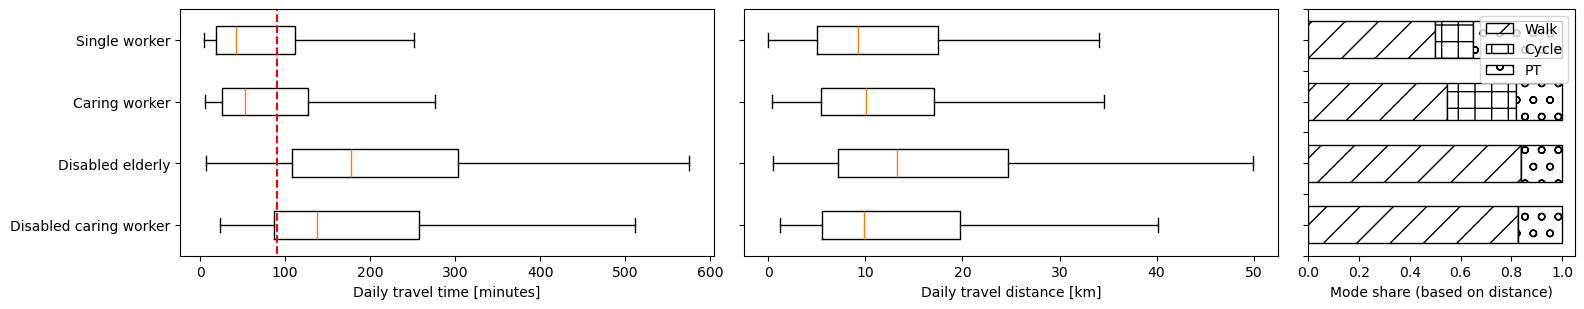

In [31]:
# Persona boxplots
fig, ax = plt.subplots(1, 3, figsize=(figsize,len(model.segments)*0.8), width_ratios=[2,2,1])
days = 21
times = []
distances = []
mode_list = ['Walk', 'Cycle', 'PT', 'MIT']
if scenario == 'car_free_':
    mode_list = ['Walk', 'Cycle', 'PT']
mode_shares = pd.DataFrame(index=mode_list)
for persona in model.segments:
    home_times = []
    home_dists = []
    home_modes = []
    for home in results[persona]['home'].unique():
        data = results[persona].loc[results[persona]['home']==home]
        home_times.append(sum([[time]*round(freq*days) for freq, time in data.groupby('frequency')['time'].sum().items()], []))
        home_dists.append(sum([[dist]*round(freq*days) for freq, dist in data.groupby('frequency')['length'].sum().items()], []))
        home_modes.append(data.groupby('mode').apply(lambda g: (g['length']*g['frequency']).sum()))
    times.append(sum(home_times, []))
    distances.append(sum(home_dists, []))
    home_modes.append(pd.Series([0 for m in mode_list], index=mode_list))
    mode_shares[persona] = pd.concat(home_modes).groupby(level=0).sum().loc[mode_list]
ax[0].boxplot(times[::-1], sym='', vert=False)#orientation='horizontal')
ax[0].set_xlabel('Daily travel time [minutes]')
ax[0].set_yticklabels(model.segments[::-1])
ax[0].vlines(x=90, ymin=0, ymax=len(model.segments)+1, colors='red', linestyles='dashed')
ax[0].set_ylim(0.5, len(model.segments)+0.5)
ax[1].boxplot(distances[::-1], sym='', vert=False)#orientation='horizontal')
ax[1].set_xlabel('Daily travel distance [km]')
ax[1].set_ylim(0.5, len(model.segments)+0.5)
ax[1].set_yticklabels([])
mode_shares = mode_shares / mode_shares.sum()
for mode, style in zip(mode_list, ['/', '+', 'o', 'X'][:len(mode_list)]):
    if mode_list.index(mode) == 0:
        left = [0 for p in model.segments]
    else:
        left = mode_shares.loc[:mode].sum()-mode_shares.loc[mode]
    ax[2].barh(list(range(1,len(model.segments)+1))[::-1], mode_shares.loc[mode], left=left,
               height=.6, label=mode, color='white', hatch=style, edgecolor='black')
ax[2].set_ylim(0.5, len(model.segments)+0.5)
ax[2].set_yticklabels([])
ax[2].set_xlabel('Mode share (based on distance)')
plt.legend()
fig.tight_layout()
plt.savefig('../output/'+region_name+'/'+scenario+'persona_time_distance_modes.png', dpi=400, bbox_inches='tight')

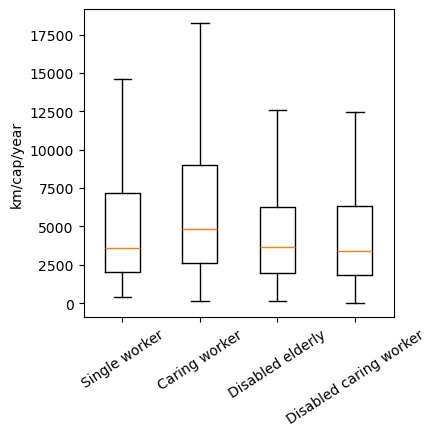

In [32]:
fig, ax = plt.subplots(1,1, figsize=(figsize/4,figsize/4))
dist_agg = [[d*365 for d in l] for l in distances[::-1]]
ax.boxplot(dist_agg, sym='')
ax.set_ylabel('km/cap/year')
ax.set_xticklabels(model.segments, rotation=33)
plt.savefig('../output/'+region_name+'/'+scenario+'persona_annual_distance.png', dpi=400, bbox_inches='tight')

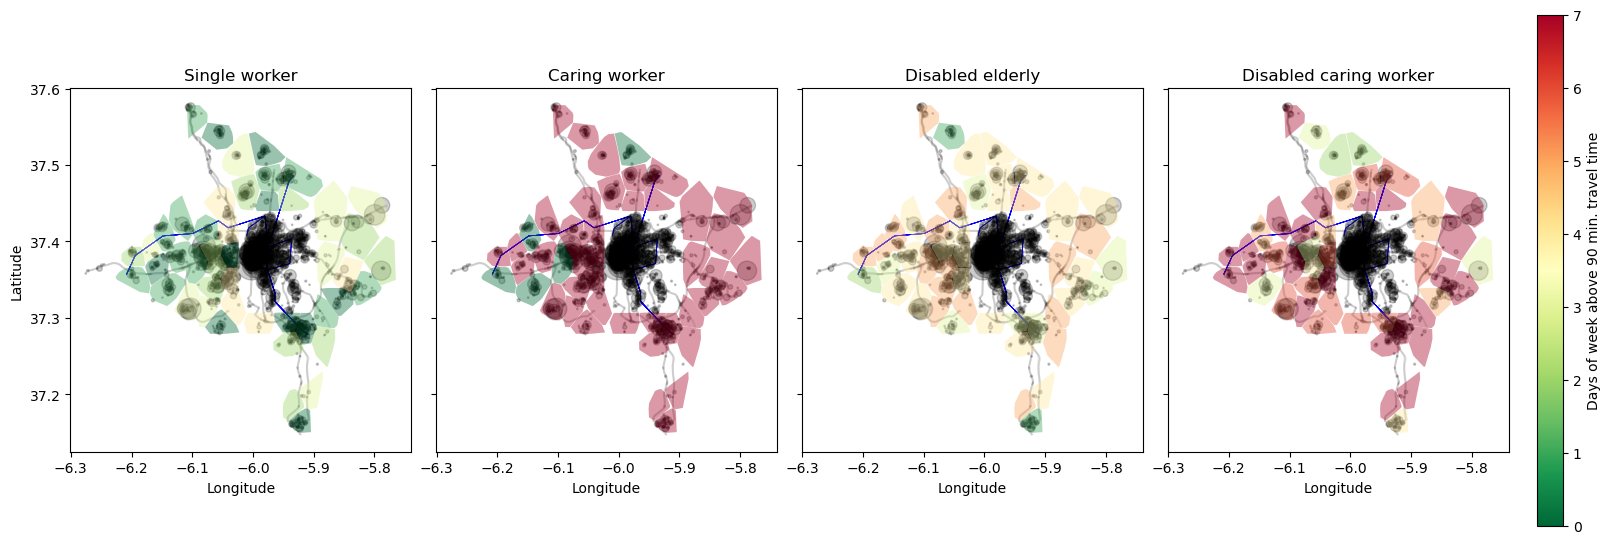

In [33]:
# Map with decent mobility threshold by home zone
time_thresh = 90
fig, axs = plt.subplots(nrows=1, ncols=len(model.segments), figsize=(figsize,figsize/3),
                        sharex='all', sharey='all', constrained_layout=True)
for ax, persona in zip(axs, model.segments):
    dm_time = results[persona].groupby(['home', 'frequency'])['time'].apply(lambda x: x.sum() > time_thresh).unstack()
    dm_time = dm_time.sum(axis=1) / 7
    zones[persona+'_time'] = zones['cluster'].map(dm_time)
    zones.plot(column=persona+'_time', cmap='RdYlGn_r', vmin=0, vmax=1, alpha=.4, ax=ax, zorder=1)
    model.auto_links.loc[model.auto_links['highway'].isin(['motorway', 'primary', 'trunk', 'motorway_link'])
        ].plot(color='black', alpha=0.1, ax=ax, zorder=-3)
    model.pt_links.loc[model.pt_links['dep_date']=='20260611'].plot(color='blue', alpha=.2, linewidth=.5, ax=ax, zorder=-2)
    pois.plot(ax=ax, color='black', markersize=pois['dest_weight'], alpha=.2, zorder=-1)
    #cx.add_basemap(ax=ax, crs='EPSG:4326', zoom=13, source=cx.providers.CartoDB.Positron)
    ax.set_title(persona)
    ax.set_xlabel('Longitude')
axs[0].set_ylabel('Latitude')
cbar = fig.colorbar(
    cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=7), cmap="RdYlGn_r"),
    ax=axs,
    orientation="vertical",
    label='Days of week above '+str(time_thresh)+' min. travel time',
    fraction=0.02, pad=0.02)
plt.savefig('../output/'+region_name+'/'+scenario+'decent_mobility_maps_time'+str(time_thresh)+'.png', dpi=400, bbox_inches='tight')

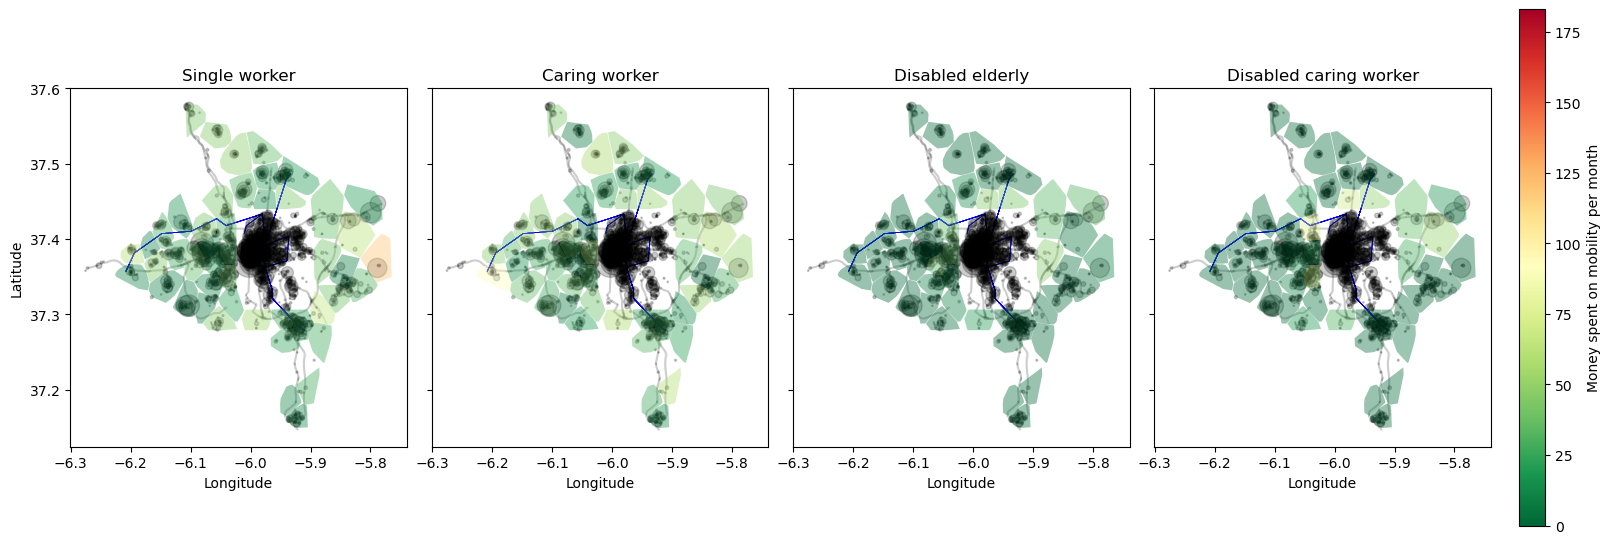

In [34]:
# Map with decent mobility threshold by home zone
# 2023, average income per employed person was ~1830
# The current discussion treats 10% of income spent on mobility as affordability threshold
if 'price' in los_attributes:
    money_thresh = 1830 * 0.1
    fig, axs = plt.subplots(nrows=1, ncols=len(model.segments), figsize=(figsize,figsize/3),
                            sharex='all', sharey='all', constrained_layout=True)
    for ax, persona in zip(axs, model.segments):
        zones[persona+'_money'] = zones['cluster'].map(results[persona].groupby('home')['price'].sum() * 4.3) # spending per month
        zones.plot(column=persona+'_money', cmap='RdYlGn_r', vmin=0, vmax=money_thresh, alpha=.4, ax=ax, zorder=1)
        model.auto_links.loc[model.auto_links['highway'].isin(['motorway', 'primary', 'trunk', 'motorway_link'])
            ].plot(color='black', alpha=0.1, ax=ax, zorder=-3)
        model.pt_links.loc[model.pt_links['dep_date']=='20260611'].plot(color='blue', alpha=.2, linewidth=.5, ax=ax, zorder=-2)
        pois.plot(ax=ax, color='black', markersize=pois['dest_weight'], alpha=.2, zorder=-1)
        #cx.add_basemap(ax=ax, crs='EPSG:4326', zoom=13, source=cx.providers.CartoDB.Positron)
        ax.set_title(persona)
        ax.set_xlabel('Longitude')
    axs[0].set_ylabel('Latitude')
    cbar = fig.colorbar(
        cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=money_thresh), cmap="RdYlGn_r"),
        ax=axs,
        orientation="vertical",
        label='Money spent on mobility per month',
        fraction=0.02, pad=0.02)
    plt.savefig('../output/'+region_name+'/'+scenario+'decent_mobility_maps_money.png', dpi=400, bbox_inches='tight')

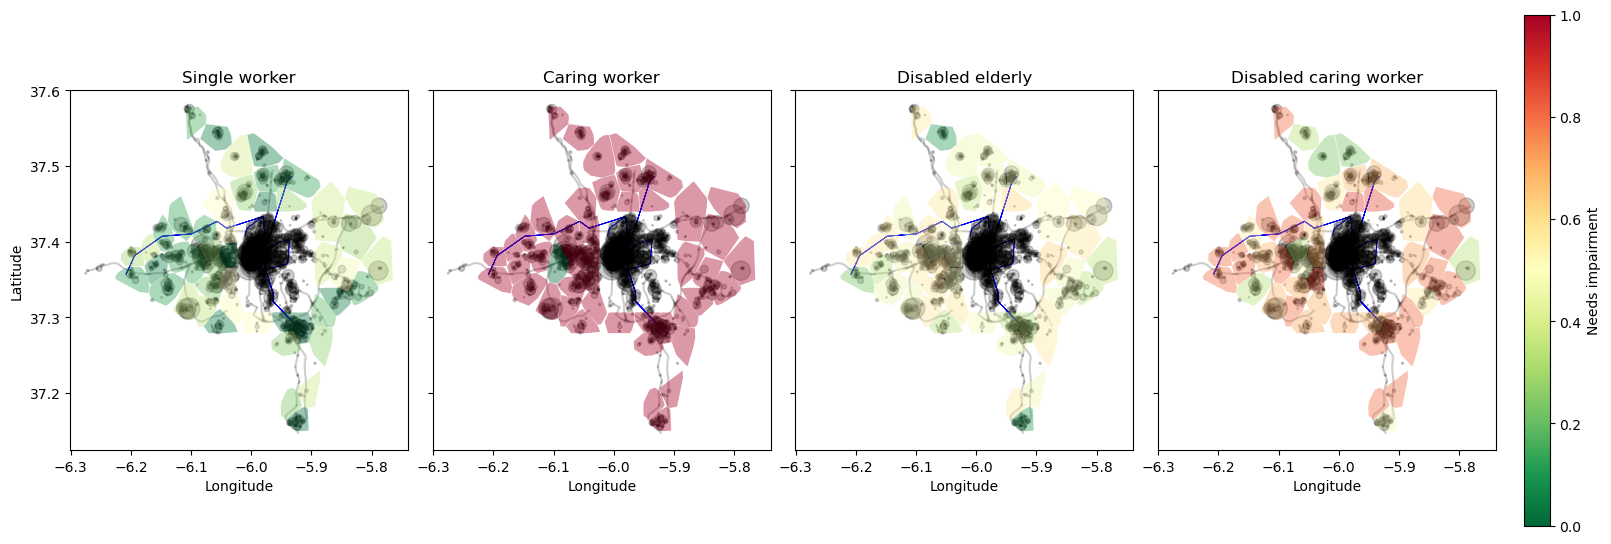

In [35]:
# Map with integrated needs impairment metric
fig, axs = plt.subplots(nrows=1, ncols=len(model.segments), figsize=(figsize,figsize/3),
                        sharex='all', sharey='all', constrained_layout=True)
for ax, persona in zip(axs, model.segments):
    zones[persona] = zones[persona+'_time'] * 0.8 + zones[persona+'_money']/money_thresh * 0.2
    zones.plot(column=persona, cmap='RdYlGn_r', vmin=0, vmax=1, alpha=.4, ax=ax, zorder=1)
    model.auto_links.loc[model.auto_links['highway'].isin(['motorway', 'primary', 'trunk', 'motorway_link'])
        ].plot(color='black', alpha=0.1, ax=ax, zorder=-3)
    model.pt_links.loc[model.pt_links['dep_date']=='20260611'].plot(color='blue', alpha=.2, linewidth=.5, ax=ax, zorder=-2)
    pois.plot(ax=ax, color='black', markersize=pois['dest_weight'], alpha=.2, zorder=-1)
    #cx.add_basemap(ax=ax, crs='EPSG:4326', zoom=13, source=cx.providers.CartoDB.Positron)
    ax.set_title(persona)
    ax.set_xlabel('Longitude')
axs[0].set_ylabel('Latitude')
cbar = fig.colorbar(
    cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=1), cmap="RdYlGn_r"),
    ax=axs,
    orientation="vertical",
    label='Needs impairment',
    fraction=0.02, pad=0.02)
plt.savefig('../output/'+region_name+'/'+scenario+'decent_mobility_maps_needs_impairment.png', dpi=400, bbox_inches='tight')